# Task 9: Loan Approval Prediction
### Predict if a loan will be Approved or Rejected based on credit history, income, and collateral

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings("ignore")


In [2]:
np.random.seed(42)
n = 30
credit_history = np.random.choice(["Good","Fair","Poor"], n, p=[0.45,0.35,0.20])
income_level   = np.random.choice(["High","Medium","Low"],  n, p=[0.35,0.40,0.25])
collateral     = np.random.choice(["Yes","No"],              n, p=[0.55,0.45])

def loan_label(ch, il, col):
    score = 0
    if ch == "Good":   score += 3
    elif ch == "Fair": score += 1
    if il == "High":   score += 3
    elif il == "Medium": score += 1
    if col == "Yes":   score += 2
    return "Approved" if score >= 4 else "Rejected"

results = [loan_label(c,i,col) for c,i,col in zip(credit_history, income_level, collateral)]
# Add slight noise
df = pd.DataFrame({
    "credit_history": credit_history,
    "income_level":   income_level,
    "collateral":     collateral,
    "loan_status":    results
})
print(df.to_string(index=False))
print("\nLoan Status Distribution:")
print(df["loan_status"].value_counts())


credit_history income_level collateral loan_status
          Good       Medium        Yes    Approved
          Poor         High        Yes    Approved
          Fair         High         No    Approved
          Fair          Low        Yes    Rejected
          Good          Low        Yes    Approved
          Good          Low        Yes    Approved
          Good         High        Yes    Approved
          Poor         High         No    Rejected
          Fair       Medium        Yes    Approved
          Fair       Medium         No    Rejected
          Good         High         No    Approved
          Poor       Medium        Yes    Rejected
          Poor         High        Yes    Approved
          Good          Low         No    Rejected
          Good         High         No    Approved
          Good       Medium         No    Approved
          Good         High         No    Approved
          Fair       Medium        Yes    Approved
          Good       Medium    

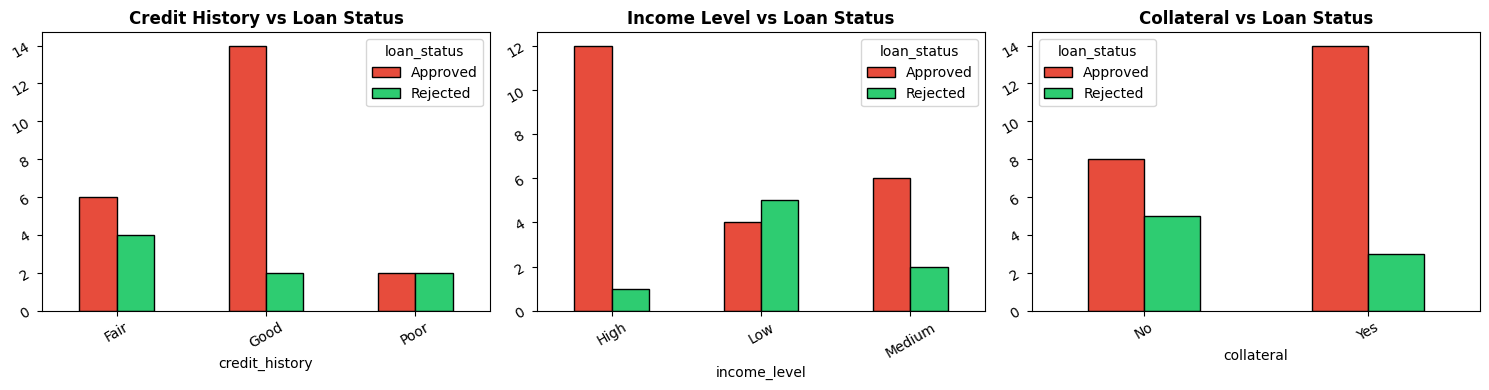

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["credit_history","income_level","collateral"]):
    pd.crosstab(df[feat], df["loan_status"]).plot(kind="bar", ax=ax,
        color=["#e74c3c","#2ecc71"], edgecolor="black")
    ax.set_title(f"{feat.replace('_',' ').title()} vs Loan Status", fontweight="bold")
    ax.tick_params(rotation=30)
plt.tight_layout(); plt.savefig("task9_viz.png", dpi=100); plt.show()


In [3]:
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop("loan_status", axis=1)
y = df_enc["loan_status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Approved","Rejected"]))


 Accuracy: 50.0 %

 Classification Report:
              precision    recall  f1-score   support

    Approved       1.00      0.43      0.60         7
    Rejected       0.20      1.00      0.33         1

    accuracy                           0.50         8
   macro avg       0.60      0.71      0.47         8
weighted avg       0.90      0.50      0.57         8



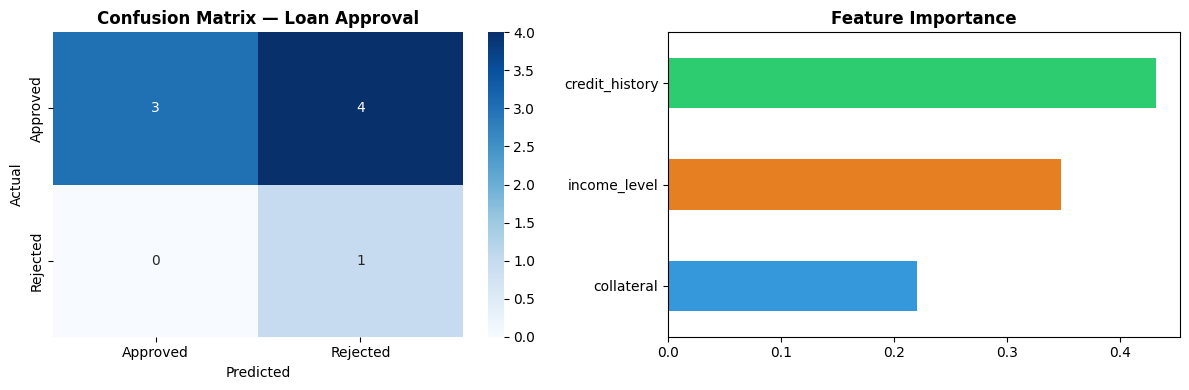

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Approved","Rejected"], yticklabels=["Approved","Rejected"])
axes[0].set_title("Confusion Matrix — Loan Approval", fontweight="bold")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh", ax=axes[1], color=["#3498db","#e67e22","#2ecc71"])
axes[1].set_title("Feature Importance", fontweight="bold")
plt.tight_layout(); plt.savefig("task9_cm.png", dpi=100); plt.show()
